## Fashion Items Classification 

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

### Load dataset

In [83]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


In [84]:
print("Missing values in x_train:", np.isnan(x_train).sum())
print("Missing values in x_test:", np.isnan(x_test).sum())

Missing values in x_train: 0
Missing values in x_test: 0


Define class names

In [85]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### EDA

In [86]:
# Basic dataset overview
print("Unique Labels:", np.unique(y_train))
print("Training Samples:", len(x_train))
print("Testing Samples:", len(x_test))
print("Image shape:", x_train[0].shape)
print("Pixel range:", x_train.min(), "to", x_train.max())

# Class count summary
label_counts = pd.Series(y_train).value_counts().sort_index().reset_index()
label_counts.columns = ['label', 'count']
label_counts['class_name'] = label_counts['label'].map(lambda x: class_names[x])
print("\nClass counts:")
print(label_counts)


Unique Labels: [0 1 2 3 4 5 6 7 8 9]
Training Samples: 60000
Testing Samples: 10000
Image shape: (28, 28)
Pixel range: 0 to 255

Class counts:
   label  count   class_name
0      0   6000  T-shirt/top
1      1   6000      Trouser
2      2   6000     Pullover
3      3   6000        Dress
4      4   6000         Coat
5      5   6000       Sandal
6      6   6000        Shirt
7      7   6000      Sneaker
8      8   6000          Bag
9      9   6000   Ankle boot


Dataset distribution

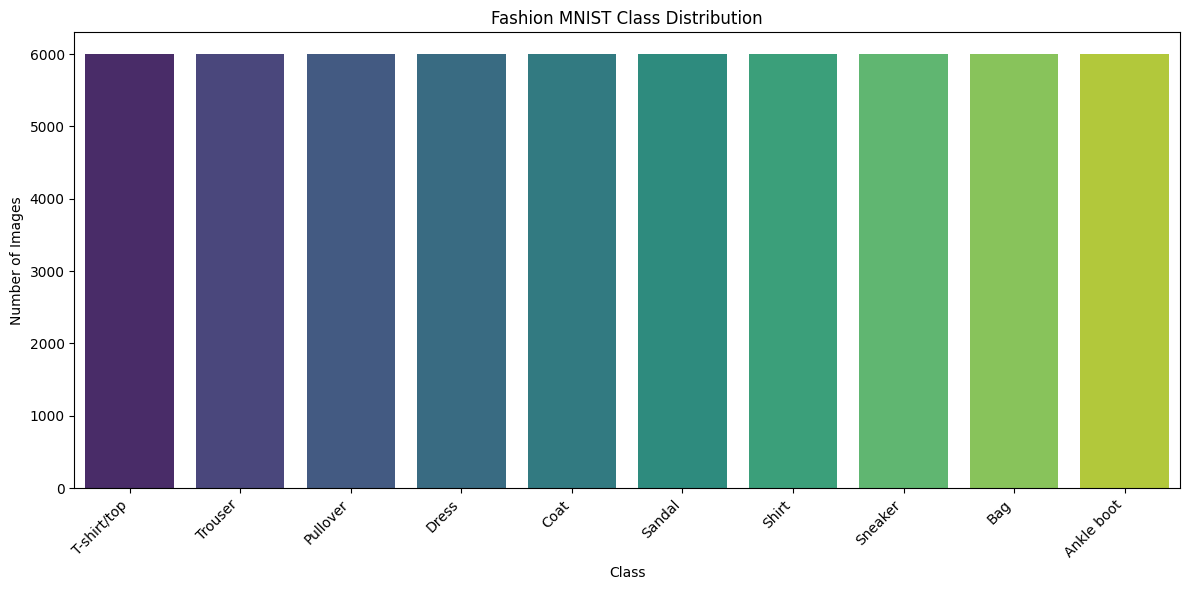

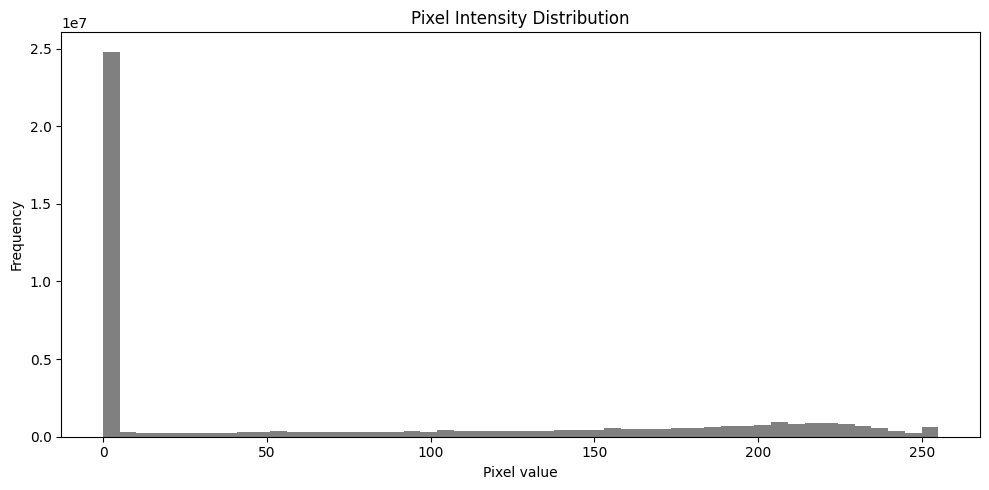

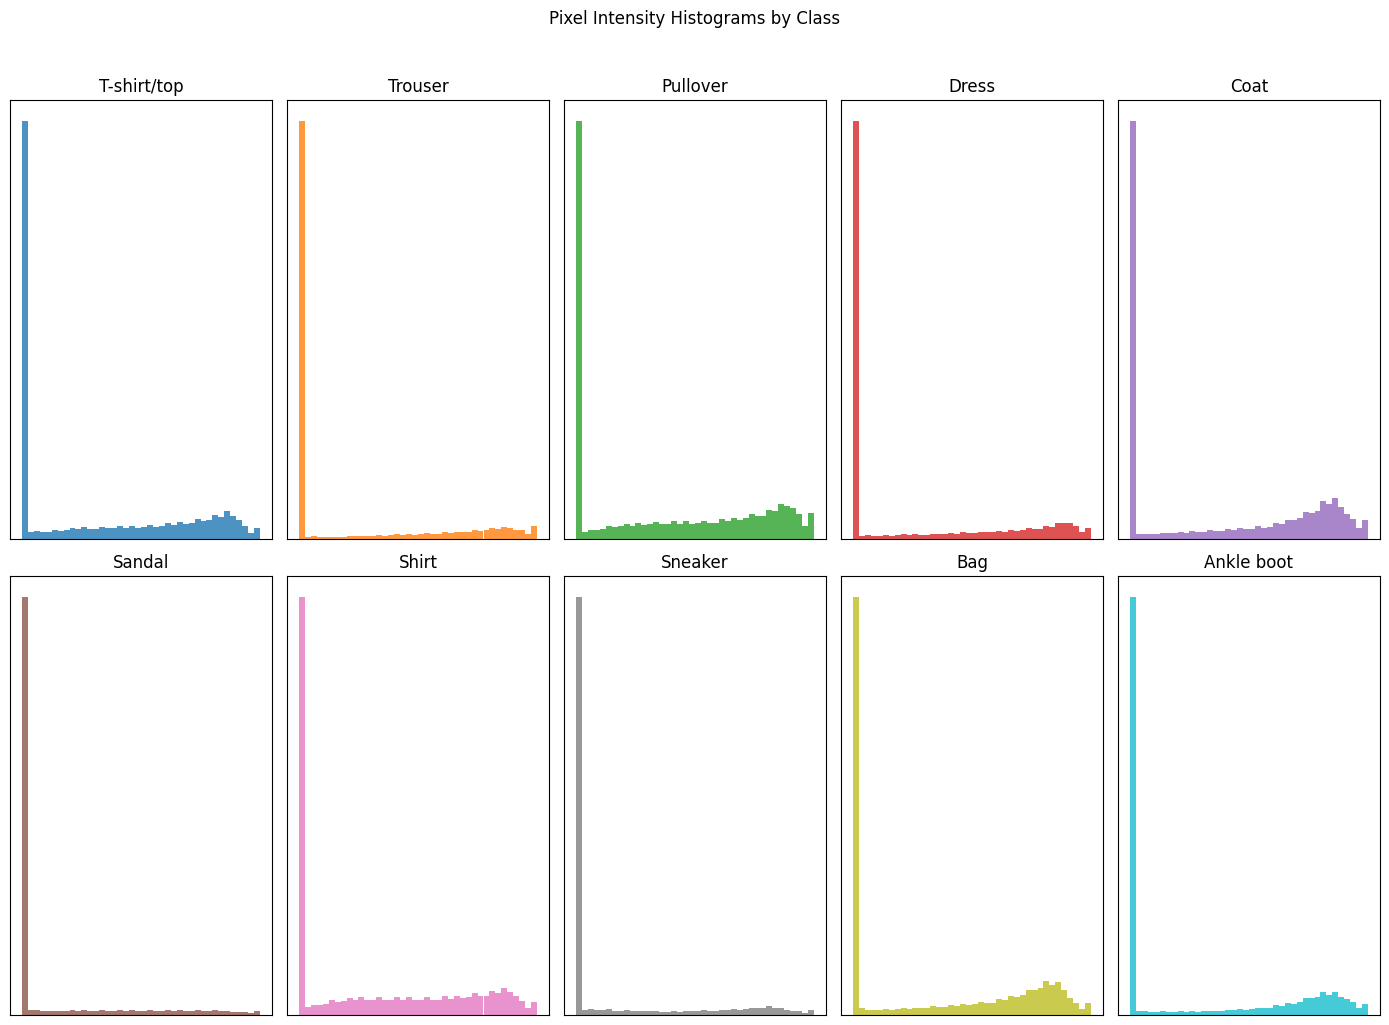

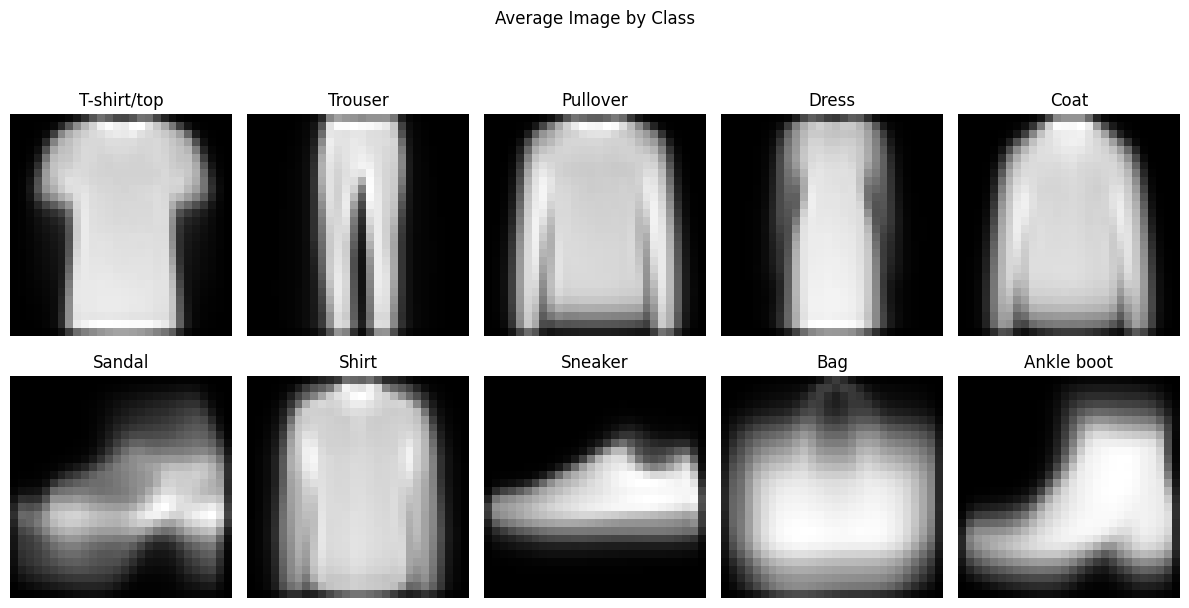

In [87]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='class_name',
    y='count',
    data=label_counts,
    palette='viridis'
)

plt.title("Fashion MNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(x_train.ravel(), bins=50, color='gray')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,10))
for idx in range(10):
    plt.subplot(2,5,idx+1)
    plt.hist(
        x_train[y_train == idx].ravel(),
        bins=40,
        color='C{}'.format(idx),
        alpha=0.8
    )
    plt.title(class_names[idx])
    plt.xticks([])
    plt.yticks([])

plt.suptitle('Pixel Intensity Histograms by Class', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
for idx in range(10):
    mean_image = x_train[y_train == idx].mean(axis=0)
    plt.subplot(2,5,idx+1)
    plt.imshow(mean_image, cmap='gray')
    plt.title(class_names[idx])
    plt.axis('off')

plt.suptitle('Average Image by Class', y=1.05)
plt.tight_layout()
plt.show()


Visualize sample images

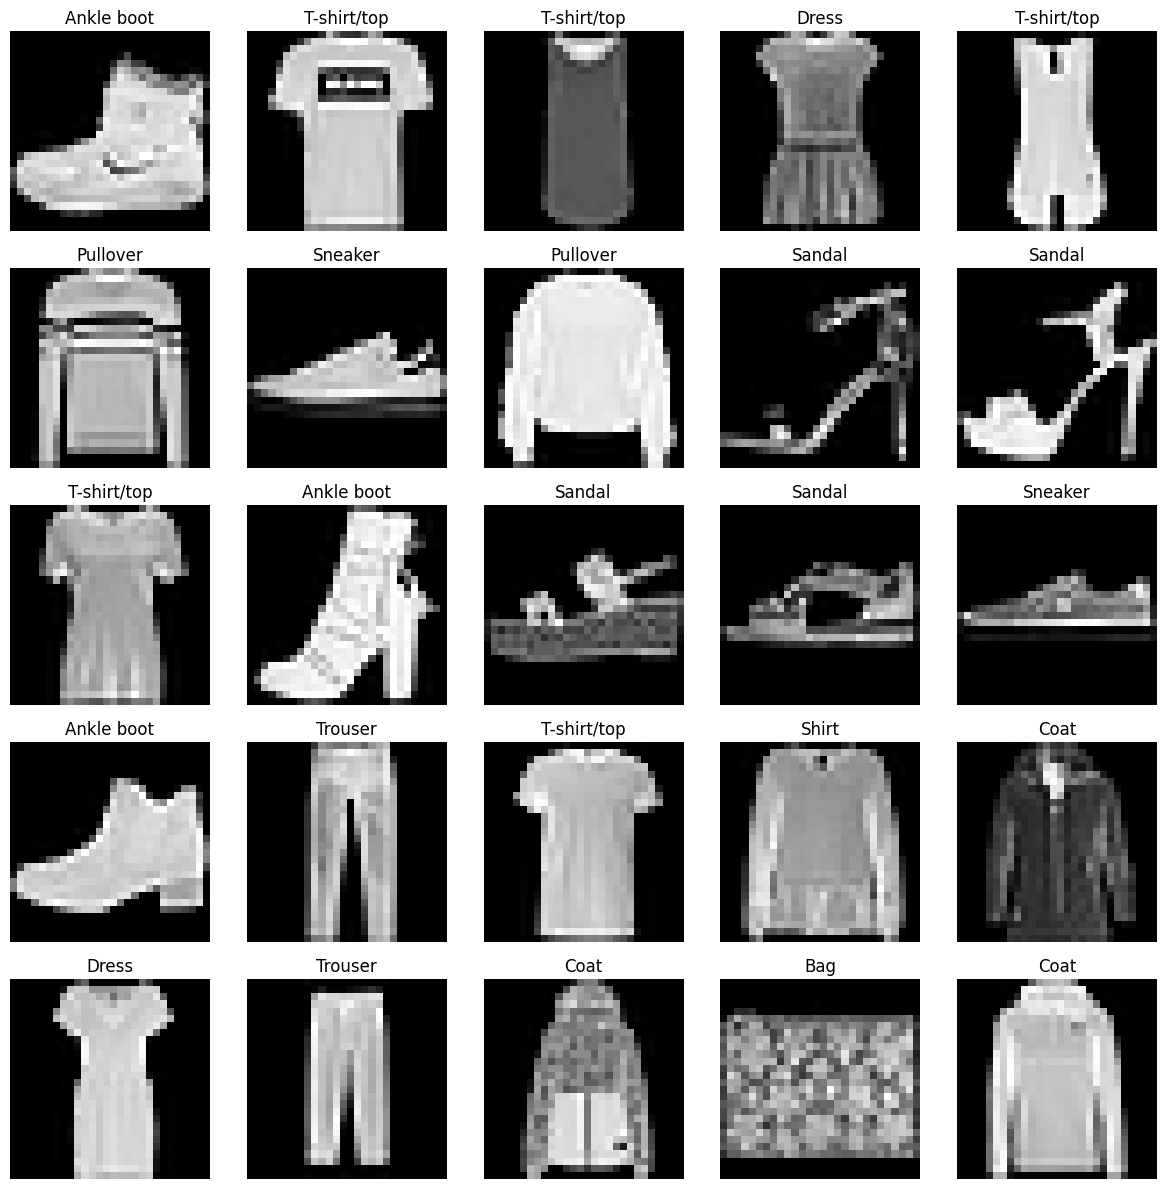

In [88]:
plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.imshow(x_train[i], cmap='gray')

    plt.title(class_names[y_train[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

### Data Preprocessing

In [89]:
# normalize the pixel values (0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Normalization Completed")

Normalization Completed


Reshape for CNN

In [90]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print("New Shape:", x_train.shape)

New Shape: (60000, 28, 28, 1)


### One-Hot Encode Labels

In [91]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
print(y_train_cat.shape)

(60000, 10)


### Data Augmentation

In [92]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

print("Data Augmentation Ready")

Data Augmentation Ready


## CNN Model

In [93]:
model = Sequential()

# First CNN Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(MaxPooling2D((2,2)))

# Second CNN Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout for Regularization
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [94]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [95]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


### Early Stopping

In [96]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Early Stopping Ready")

Early Stopping Ready


Model Summary

In [97]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [98]:
history = model.fit(
    datagen.flow(x_train, y_train_cat, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test_cat),
    callbacks=[early_stop]
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.6970 - loss: 0.8138 - val_accuracy: 0.8017 - val_loss: 0.5017
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.7760 - loss: 0.5939 - val_accuracy: 0.8166 - val_loss: 0.4621
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8013 - loss: 0.5280 - val_accuracy: 0.8480 - val_loss: 0.4060
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.8190 - loss: 0.4869 - val_accuracy: 0.8586 - val_loss: 0.3715
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8315 - loss: 0.4559 - val_accuracy: 0.8767 - val_loss: 0.3330
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8406 - loss: 0.4359 - val_accuracy: 0.8756 - val_loss: 0.3359
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8469 - loss: 0.4193 - val_accuracy: 0.8814 - val_loss: 0.3194
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8468 - loss: 0.4115 - 

### Evaluate model (with test data)

In [99]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat
)

print("\nTest Accuracy:", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8818 - loss: 0.3168

Test Accuracy: 88.17999958992004


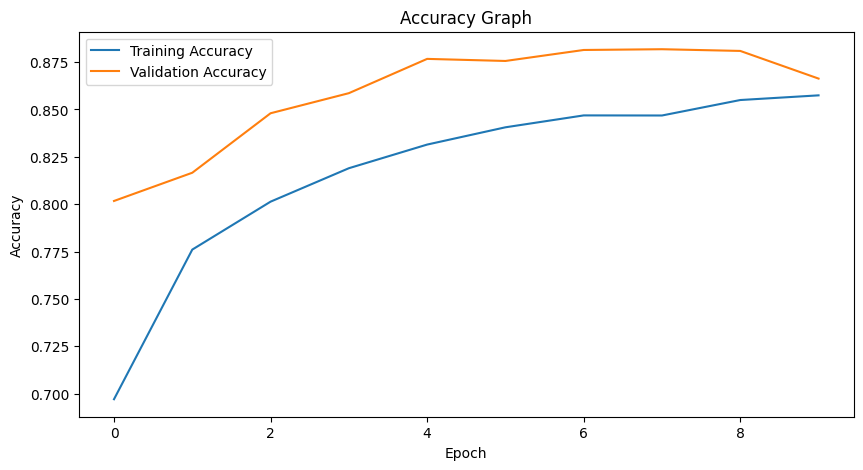

In [100]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

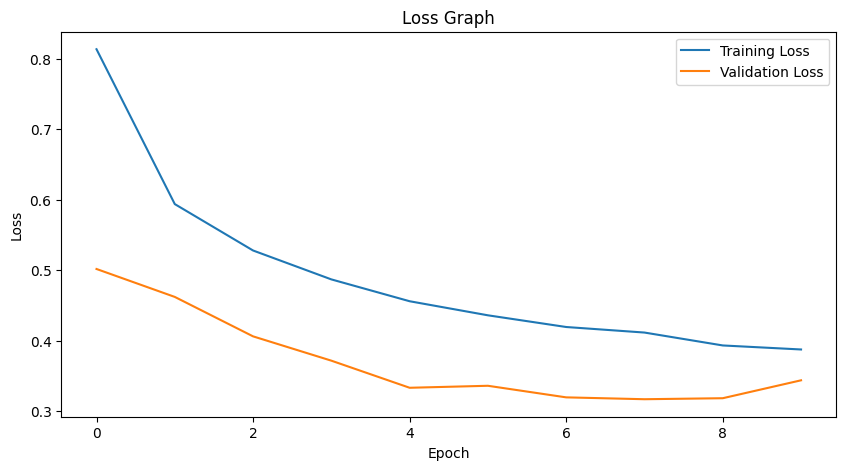

In [101]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

### Predict test images

In [102]:
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


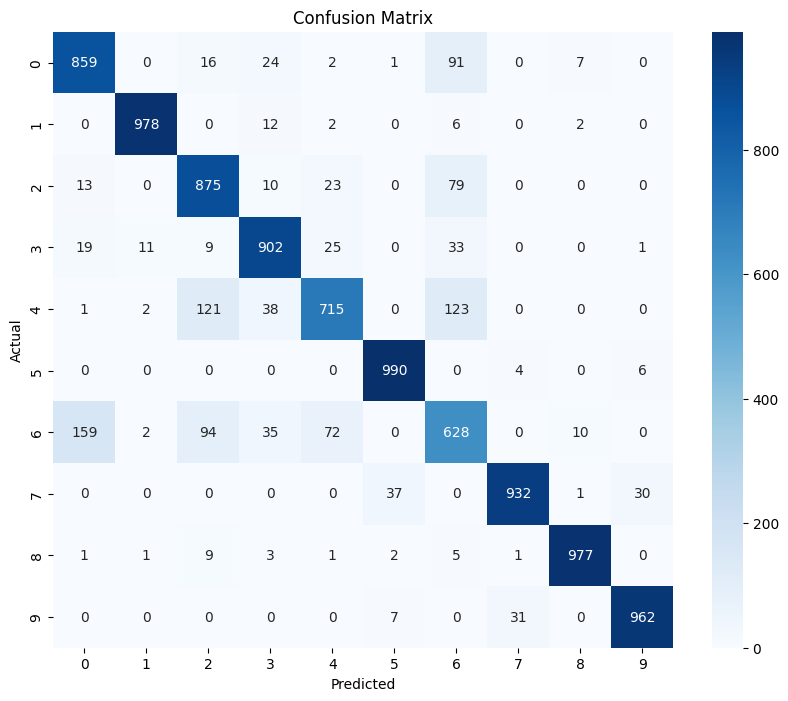

In [103]:
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [104]:
print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.78      0.88      0.82      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.85      0.71      0.78      1000
      Sandal       0.95      0.99      0.97      1000
       Shirt       0.65      0.63      0.64      1000
     Sneaker       0.96      0.93      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### Sample Prediction Visualization

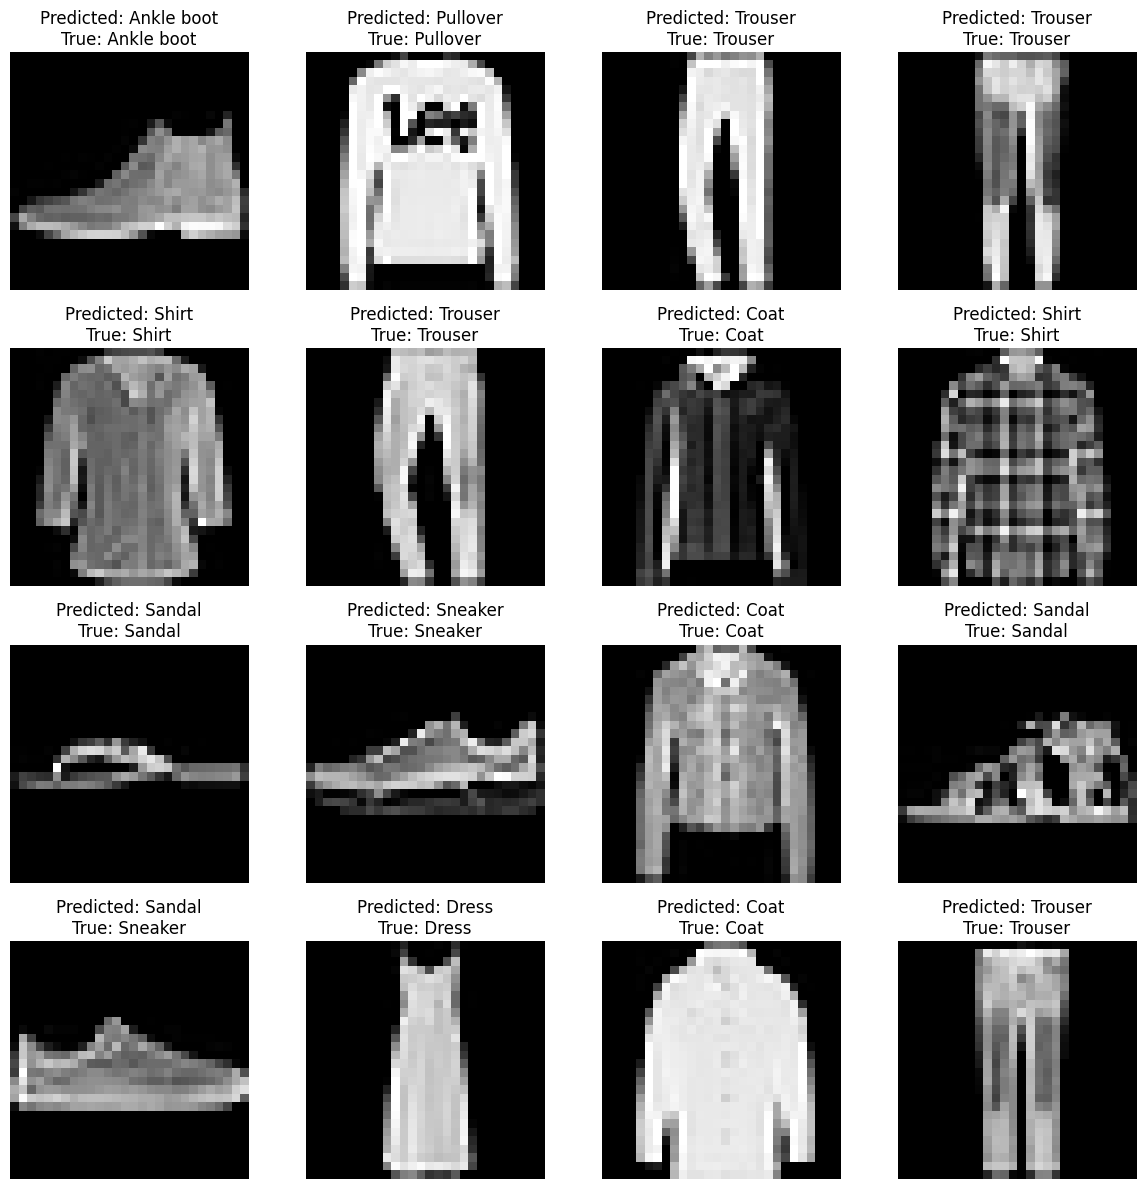

In [105]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    predicted_label = class_names[predicted_classes[i]]
    true_label = class_names[y_test[i]]

    plt.title(f"Predicted: {predicted_label}\nTrue: {true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

SAVE the Model

In [106]:
model.save("saved_model/my_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


Original image --> Resize to 28x28


Image converted successfully!


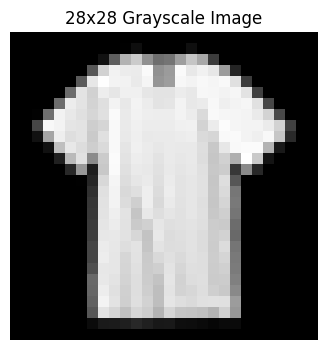

In [107]:
from PIL import Image
import matplotlib.pyplot as plt


image_path = "samples/sample1.jpg"

# LOAD IMAGE
image = Image.open(image_path)

# CONVERT TO GRAYSCALE
gray_image = image.convert("L")

# RESIZE TO 28x28
resized_image = gray_image.resize((28, 28))


# SAVE IMAGE
output_path = "28x28/converted_image.png"
resized_image.save(output_path)
print("Image converted successfully!")

# ========================================== #
# DISPLAY IMAGE
plt.figure(figsize=(4,4))
plt.imshow(resized_image, cmap='gray')
plt.title("28x28 Grayscale Image")
plt.axis("off")
plt.show()

### (Normal Images) - Predict System

Model Loaded Successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step

Prediction:
Class: Shirt
Confidence: 42.41%


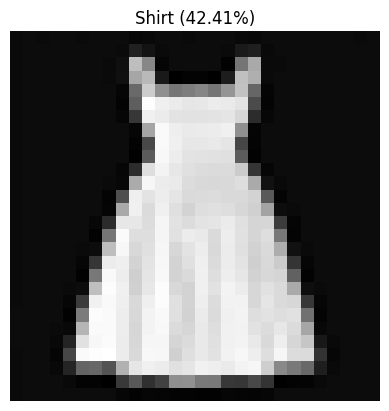


Top 3 Predictions:
Shirt: 42.41%
Dress: 25.45%
T-shirt/top: 20.03%


In [108]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from tensorflow.keras.models import load_model


##### CLASS NAMES

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]


# LOAD MODEL
model = load_model("saved_model/my_model.keras")
print("Model Loaded Successfully")

# LOAD IMAGE
image_path = "samples/sample2.jpg"
image = Image.open(image_path)

# Convert to grayscale
image = image.convert("L")

# Optional inversion (remove if results look wrong)
image = ImageOps.invert(image)

# Resize to 28x28
image = image.resize((28, 28))

# Convert to array
image_array = np.array(image)

# Normalize
image_array = image_array / 255.0

# Reshape for CNN
image_array = image_array.reshape(1, 28, 28, 1)




# PREDICT

prediction = model.predict(image_array)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100



print("\nPrediction:")
print(f"Class: {class_names[predicted_class]}")
print(f"Confidence: {confidence:.2f}%")


########### VISUALIZATION
plt.imshow(image_array.reshape(28,28), cmap='gray')
plt.title(f"{class_names[predicted_class]} ({confidence:.2f}%)")
plt.axis('off')
plt.show()


########## TOP 3 PREDICTIONS
top_3 = np.argsort(prediction[0])[::-1][:3]

print("\nTop 3 Predictions:")
for i in top_3:
    print(f"{class_names[i]}: {prediction[0][i]*100:.2f}%")